In [2]:
pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.5 MB 2.4 MB/s eta 0:00:04
   ----- ---------------------------------- 1.3/9.5 MB 2.6 MB/s eta 0:00:04
   -------- ------------------------------- 2.1/9.5 MB 2.8 MB/s eta 0:00:03
   ----------- ---------------------------- 2.6/9.5 MB 2.8 MB/s eta 0:00:03
   -------------- ------------------------- 3.4/9.5 MB 3.0 MB/s eta 0:00:03
   ----------------- ---------------------- 4.2/9.5 MB 3.1 MB/s eta 0:00:02
   -------------------- ------------------- 5.0/9.5 MB 3.2 MB/s eta 0:00:02
   ------------------------ --------------- 5.8/9.5 MB 3.3 MB/s eta 0:00:02
   --------------------------- ------------ 6.6/9.5 MB 3.3 MB/s eta 0:00:01
   ------------------------------ --------- 7.3/9.5 MB 3.4 MB/s eta 0:00:01
   ---------------------------------- 


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: C:\Users\ashish\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip


In [4]:
df = pd.read_csv("plot_price_data.csv")

print(df.head())
print("Shape:", df.shape)
print(df.isnull().sum())

   area    price
0   901  1882000
1  3983  7234000
2  3446  6346000
3  2475  4850000
4  2449  4555000
Shape: (200, 2)
area     0
price    0
dtype: int64


In [5]:
X = df[["area"]]     # input: plot area
y = df["price"]      # output: price

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (200, 1)
y shape: (200,)


In [6]:
from sklearn.model_selection import train_test_split

train_x, test_x, train_y, test_y = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(len(train_x), len(test_x))

160 40


In [7]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(train_x, train_y)

print("R2 Score:", model.score(test_x, test_y))
print("Price per sq ft (coef):", model.coef_[0])
print("Intercept:", model.intercept_)

R2 Score: 0.9956825235029203
Price per sq ft (coef): 1791.9806680161269
Intercept: 216162.0377924461


In [8]:
from sklearn.metrics import mean_absolute_error, r2_score

pred_y = model.predict(test_x)

print("MAE:", mean_absolute_error(test_y, pred_y))
print("R2 :", r2_score(test_y, pred_y))

MAE: 115722.04354953827
R2 : 0.9956825235029203


In [9]:
index = 1

prediction = model.predict(test_x.iloc[[index]])[0]

print("Area:", test_x.iloc[index]["area"])
print("Predicted Price:", round(prediction))
print("Actual Price:", test_y.iloc[index])

Area: 4038
Predicted Price: 7452180
Actual Price: 7251000


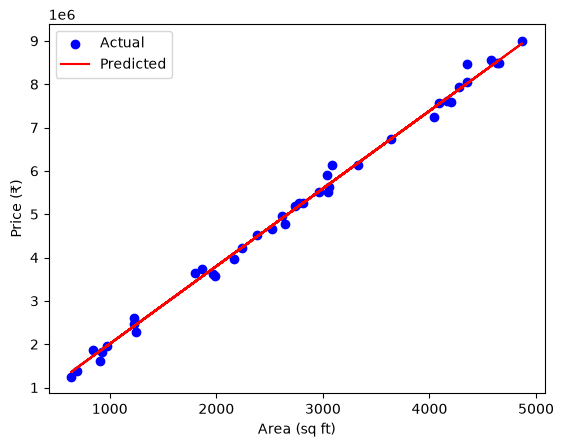

In [10]:
plt.scatter(test_x, test_y, color="blue", label="Actual")
plt.plot(test_x, pred_y, color="red", label="Predicted")
plt.xlabel("Area (sq ft)")
plt.ylabel("Price (₹)")
plt.legend()
plt.show()